In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# display all rows and columns
df = pd.read_csv('library-dataset.csv')
pd.set_option('display.width', 10000)


print(df.head())

                                       Title          Author  My Rating    Binding                            Date Read   Status                                            Genre  Read Count  Number of Pages
0              Onyx Storm (The Empyrean, #3)  Rebecca Yarros        5.0      ebook  January 21, 2025 → January 26, 2025  read, ♡                 Adult, fantasy, fiction, romance         1.0              527
1      Nightshade (Sorrowsong University #1)   Autumn  Woods        5.0      ebook  February 2, 2025 → February 4, 2025     read                fantasy, mystery, romance, sports         1.0              359
2              Limerence (Fated Fixation #1)    H.C. Dolores        0.0        NaN                                  NaN      NaN                                              NaN         0.0              415
3  Broken Whispers (Perfectly Imperfect, #2)      Neva Altaj        0.0        NaN                                  NaN      NaN                                            

In [5]:
df = df.drop(columns=['Binding', 'Read Count'])

#removes extra characters from status
df['Status'] = df['Status'].apply(
    lambda x: x.split(',')[0].strip() if isinstance(x, str) else pd.NA
)


#separate start date and end date
df['Start'] = df['Date Read'].apply(
    lambda x: x.split(' → ')[0].strip() if isinstance(x, str) else pd.NA
)

df['End'] = df['Date Read'].apply(
    lambda x: x.split(' → ')[1].strip() if isinstance(x, str) and ' → ' in x else x
)

df = df.drop(columns=['Date Read'])

print(df.head())


                                       Title          Author  My Rating Status                                            Genre  Number of Pages             Start               End
0              Onyx Storm (The Empyrean, #3)  Rebecca Yarros        5.0   read                 Adult, fantasy, fiction, romance              527  January 21, 2025  January 26, 2025
1      Nightshade (Sorrowsong University #1)   Autumn  Woods        5.0   read                fantasy, mystery, romance, sports              359  February 2, 2025  February 4, 2025
2              Limerence (Fated Fixation #1)    H.C. Dolores        0.0    NaN                                              NaN              415               NaN               NaN
3  Broken Whispers (Perfectly Imperfect, #2)      Neva Altaj        0.0    NaN                                              NaN              232               NaN               NaN
4                               The Stranger    Albert Camus        3.0   read  classics, ficti

In [6]:
#fill in missing data
df['Status'] = df['Status'].fillna('tbr')
df['Start'] = df['Start'].fillna('Unknown')
df['End'] = df['End'].fillna('Unknown')
df['Genre'] = df['Genre'].fillna('Unknown')
df['Genre'] = df['Genre'].str.split(',')

# remove books with no dates
df = df[df['Start'] != 'Unknown']

print(df.head())

                                    Title          Author  My Rating Status                                              Genre  Number of Pages               Start                 End
0           Onyx Storm (The Empyrean, #3)  Rebecca Yarros        5.0   read              [Adult,  fantasy,  fiction,  romance]              527    January 21, 2025    January 26, 2025
1   Nightshade (Sorrowsong University #1)   Autumn  Woods        5.0   read             [fantasy,  mystery,  romance,  sports]              359    February 2, 2025    February 4, 2025
4                            The Stranger    Albert Camus        3.0   read  [classics,  fiction,  literary fiction,  philo...              123    January 11, 2025    January 19, 2025
5                  The Risk (Briar U, #2)    Elle Kennedy        5.0   read          [Adult,  contemporary,  romance,  sports]              402  September 20, 2024  September 22, 2024
11           Us Dark Few (Us Dark Few #1)   Alexis Patton        1.0   read     

In [7]:
#turn Start and End to date-time
df['Start Date'] = pd.to_datetime(df['Start'], errors='coerce')
df['End Date'] = pd.to_datetime(df['End'], errors='coerce')
cutoff_date = pd.to_datetime('2024-08-01')
newdf = df[df['Start Date'] >= cutoff_date]
newdf = newdf.drop(columns=['Start', 'End'])

print(newdf.head())

                                    Title          Author  My Rating Status                                              Genre  Number of Pages Start Date   End Date
0           Onyx Storm (The Empyrean, #3)  Rebecca Yarros        5.0   read              [Adult,  fantasy,  fiction,  romance]              527 2025-01-21 2025-01-26
1   Nightshade (Sorrowsong University #1)   Autumn  Woods        5.0   read             [fantasy,  mystery,  romance,  sports]              359 2025-02-02 2025-02-04
4                            The Stranger    Albert Camus        3.0   read  [classics,  fiction,  literary fiction,  philo...              123 2025-01-11 2025-01-19
5                  The Risk (Briar U, #2)    Elle Kennedy        5.0   read          [Adult,  contemporary,  romance,  sports]              402 2024-09-20 2024-09-22
11           Us Dark Few (Us Dark Few #1)   Alexis Patton        1.0   read                     [dystopia,  fantasy,  romance]              321 2025-02-16 2025-02-18


In [8]:
#expand genres
df_explode = newdf.explode('Genre')
df_explode['Genre'] = df_explode['Genre'].str.strip()

print(df_explode)

                                     Title          Author  My Rating Status    Genre  Number of Pages Start Date   End Date
0            Onyx Storm (The Empyrean, #3)  Rebecca Yarros        5.0   read    Adult              527 2025-01-21 2025-01-26
0            Onyx Storm (The Empyrean, #3)  Rebecca Yarros        5.0   read  fantasy              527 2025-01-21 2025-01-26
0            Onyx Storm (The Empyrean, #3)  Rebecca Yarros        5.0   read  fiction              527 2025-01-21 2025-01-26
0            Onyx Storm (The Empyrean, #3)  Rebecca Yarros        5.0   read  romance              527 2025-01-21 2025-01-26
1    Nightshade (Sorrowsong University #1)   Autumn  Woods        5.0   read  fantasy              359 2025-02-02 2025-02-04
..                                     ...             ...        ...    ...      ...              ...        ...        ...
771                    A Study In Drowning        Ava Reid        2.0   read  fantasy              378 2025-10-31 2025-11-02


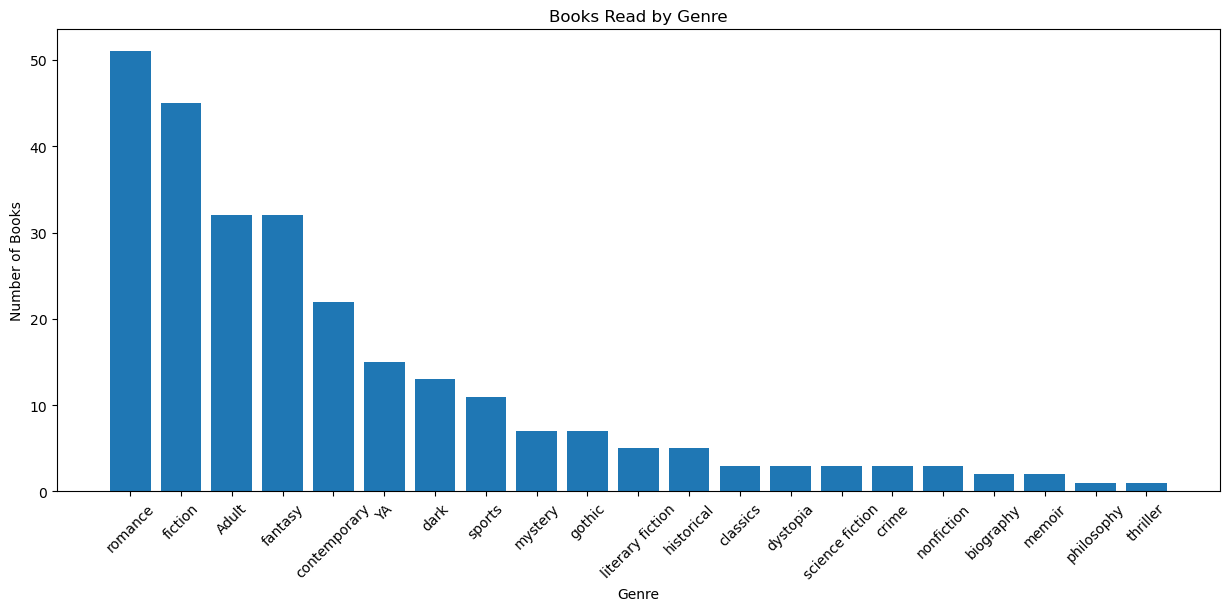

In [32]:
genre_count = df_explode['Genre'].value_counts()

plt.figure(figsize=(15, 6))
plt.bar(genre_count.index, genre_count.values)
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.title("Books Read by Genre")
plt.show()

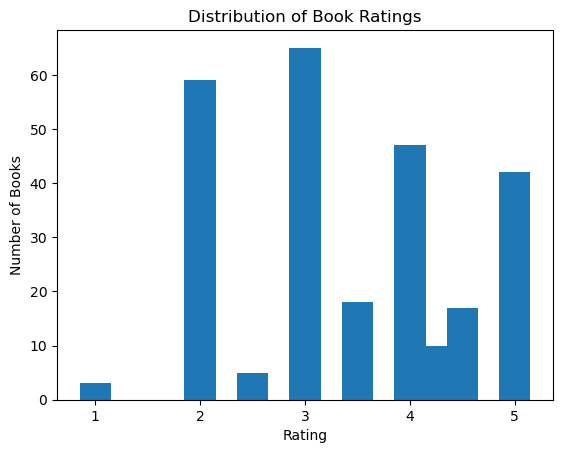

In [30]:
rating_count = df_explode['My Rating'].value_counts().sort_index()

plt.xlabel("Rating")
plt.bar(rating_count.index, rating_count.values, width=0.3)
plt.ylabel("Number of Books")
plt.title("Distribution of Book Ratings")
plt.show()